# Linear Regression From Scratch

### Objective
Implement Linear Regression using Gradient Descent without using machine learning libraries.

### Steps
1. Data Loading
2. Data Exploration
3. Outlier Detection & Removal
4. Feature Scaling
5. Train-Test Split
6. Linear Regression Implementation
7. Model Training
8. Evaluation Metrics
9. Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df=pd.read_csv("Extracted_features.csv")

In [32]:
df.head()

,has_ip,count_dots,count_hyphens,count_at,count_colon,count_slashes,count_question_marks,count_equals,count_and,count_percentage,...,count_occurrences_of_com,count_occurrences_of_www,count_double_slashes,length_without_protocol,longest_repeated_substring,levenshtein_to_common_domain,vowel_consonant_ratio,cluster_label,status,url
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,16,0,9,0.499998,0,benign,lechorepublicain.fr
1,0,2,2,0,1,4,0,0,0,0,...,0,0,1,30,0,9,0.499998,1,malicious,https://bridgtrzr-dcs.github.io/en-us/
2,0,2,0,0,1,3,0,0,0,0,...,0,0,1,15,0,9,0.499998,1,malicious,https://l.ead.me/bfUZQN
3,0,2,4,0,1,7,1,3,2,0,...,1,0,1,165,0,9,0.499998,2,malicious,https://docs.google.com/presentation/d/e/2PACX...
4,0,2,0,0,1,3,1,1,0,0,...,0,0,1,44,0,9,0.499998,1,malicious,https://kyc4w2.webwave.dev/?forcePageWithoutCd...


In [33]:
df.describe()

,has_ip,count_dots,count_hyphens,count_at,count_colon,count_slashes,count_question_marks,count_equals,count_and,count_percentage,...,count_unique_chars,ratio_special_to_total_chars,count_occurrences_of_com,count_occurrences_of_www,count_double_slashes,length_without_protocol,longest_repeated_substring,levenshtein_to_common_domain,vowel_consonant_ratio,cluster_label
count,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,...,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.000000,127656.0,127656.0,1.276560e+05,127656.000000
mean,0.005076,1.528968,0.499859,0.004089,0.509103,1.808587,0.076322,0.222167,0.147984,0.038792,...,17.394889,0.145886,0.530747,0.013435,0.507771,28.958161,0.0,9.0,4.999975e-01,0.669361
std,0.071066,0.907016,1.120614,0.068664,0.526256,2.081501,0.290076,1.070490,0.836477,1.036220,...,12.241279,0.064162,0.529948,0.117551,0.538999,112.607763,0.0,0.0,2.220455e-16,0.882553
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.003487,0.000000,0.000000,0.000000,1.000000,0.0,9.0,4.999975e-01,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.090909,0.000000,0.000000,0.000000,9.000000,0.0,9.0,4.999975e-01,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,...,14.000000,0.135000,1.000000,0.000000,0.500000,14.000000,0.0,9.0,4.999975e-01,1.000000
75%,0.000000,2.000000,1.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,...,20.000000,0.200000,1.000000,0.000000,1.000000,28.000000,0.0,9.0,4.999975e-01,1.000000
max,1.000000,33.000000,50.000000,8.000000,6.000000,104.000000,17.000000,47.000000,43.000000,192.000000,...,73.000000,0.681529,7.000000,3.000000,52.000000,25515.000000,0.0,9.0,4.999975e-01,4.000000


In [6]:
# missing values
df.isnull().sum()

has_ip                          0
count_dots                      0
count_hyphens                   0
count_at                        0
count_colon                     0
                               ..
levenshtein_to_common_domain    0
vowel_consonant_ratio           0
cluster_label                   0
status                          0
url                             0
Length: 87, dtype: int64

In [35]:
# Removing unnecessary columns
df = df.drop(columns=["url"])
features=df.columns.tolist()


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 127656 entries, 0 to 127655
Data columns (total 86 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   has_ip                                127656 non-null  int64  
 1   count_dots                            127656 non-null  int64  
 2   count_hyphens                         127656 non-null  int64  
 3   count_at                              127656 non-null  int64  
 4   count_colon                           127656 non-null  int64  
 5   count_slashes                         127656 non-null  int64  
 6   count_question_marks                  127656 non-null  int64  
 7   count_equals                          127656 non-null  int64  
 8   count_and                             127656 non-null  int64  
 9   count_percentage                      127656 non-null  int64  
 10  ratio_digits                          127656 non-null  float64
 11  has_punycod

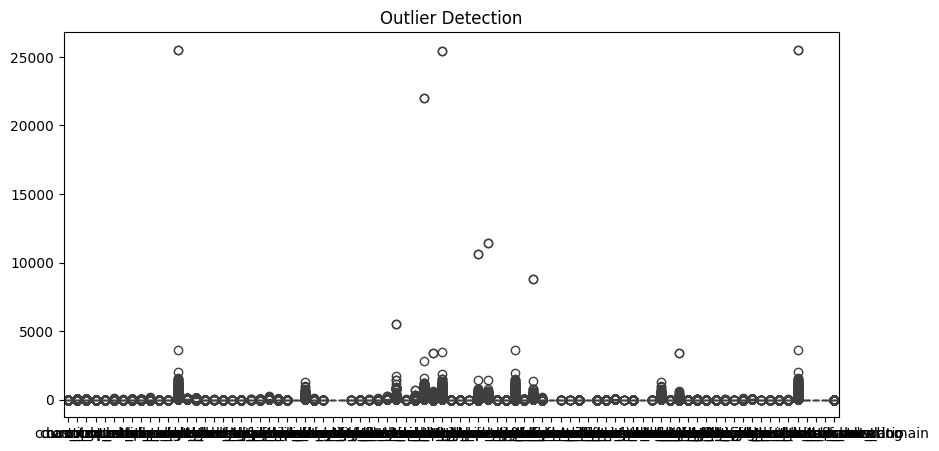

In [38]:
# outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(columns=["status"]))
plt.title("Outlier Detection")
plt.show()

In [70]:
corr_matrix = df.corr()

target_corr = corr_matrix["status"].sort_values(ascending=False)

print(target_corr)

status                               1.000000
length_of_protocol                   0.997945
count_colon                          0.967409
presence_of_hex_chars_in_hostname    0.962989
length_tld                           0.958594
                                       ...   
count_dots_in_path                  -0.822354
path_contains_executable                  NaN
longest_repeated_substring                NaN
levenshtein_to_common_domain              NaN
vowel_consonant_ratio                     NaN
Name: status, Length: 86, dtype: float64


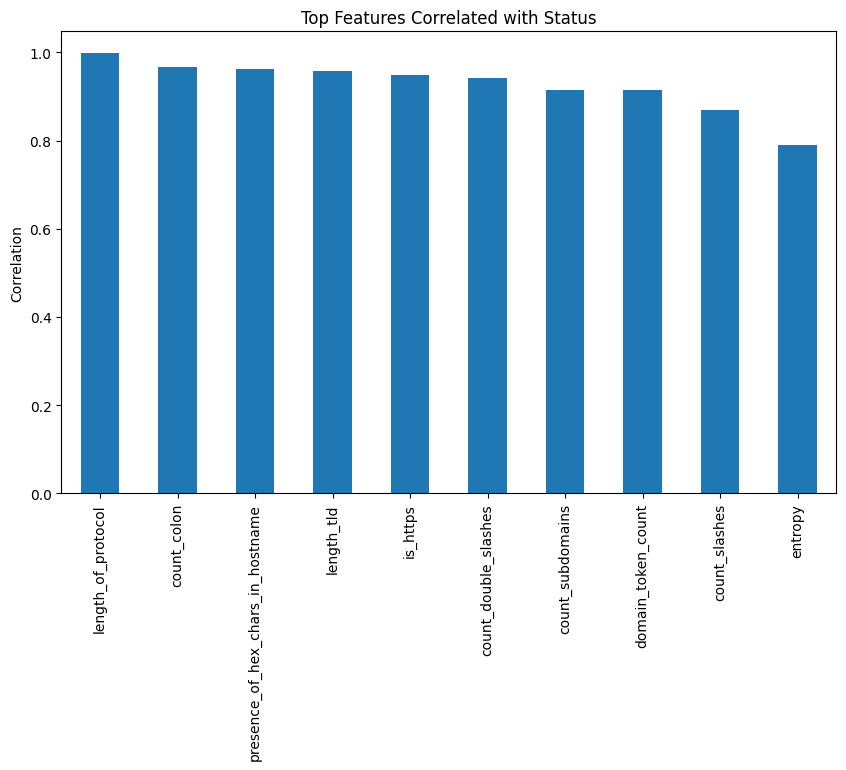

In [72]:
plt.figure(figsize=(10,6))

target_corr.drop("status").head(10).plot(kind="bar")

plt.title("Top Features Correlated with Status")
plt.ylabel("Correlation")
plt.show()

In [73]:
top_features = target_corr.abs().sort_values(ascending=False).index[1:11]

print("Selected Features:", top_features)

Selected Features: Index(['length_of_protocol', 'count_colon',
       'presence_of_hex_chars_in_hostname', 'length_tld', 'is_https',
       'count_double_slashes', 'count_subdomains', 'domain_token_count',
       'count_slashes', 'count_dots_in_path'],
      dtype='str')


In [57]:
df["status"] = df["status"].map({
    "benign": 0,
    "malicious": 1
})

In [78]:
X = df[top_features].values
y = df["status"].values

In [79]:
non_numeric = df.select_dtypes(exclude=["int64","float64"])

print(non_numeric.columns)

Index([], dtype='str')


In [80]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [81]:
class LinearRegressionScratch:
    
    def __init__(self, n_features):
        
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()
        
    def predict(self, X):
        
        return np.dot(X, self.weights) + self.bias

In [82]:
def mse(y_true, y_pred):
    
    return np.mean((y_true - y_pred) ** 2)

In [83]:
def mae(y_true, y_pred):
    
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    
    return 1 - (ss_res / ss_tot)

In [100]:
def train(model, X, y, epochs=100, lr=0.001):
    
    n = len(X)
    losses = []
    
    for epoch in range(epochs):
        
        predictions = model.predict(X)
        
        loss = mse(y, predictions)
        losses.append(loss)
        
        error = predictions - y
        
        dw = (2/n) * np.dot(X.T, error)
        db = (2/n) * np.sum(error)
        
        model.weights -= lr * dw
        model.bias -= lr * db
        
        if epoch % 20 == 0:
            print("Epoch:", epoch, "Loss:", loss)
    
    return losses

In [136]:
model = LinearRegressionScratch(X_train.shape[1])

In [ ]:
losses = train(model, X_train, y_train, epochs=100, lr=0.001)

Epoch: 0 Loss: 0.011090803007358626
Epoch: 20 Loss: 0.010677934790316332
Epoch: 40 Loss: 0.01028319706488294
Epoch: 60 Loss: 0.009905703207753858
Epoch: 80 Loss: 0.009544616315771685


In [151]:
predictions = model.predict(X_test)

print("MSE:", mse(y_test, predictions))
print("MAE:", mae(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MSE: 0.008576227939387183
MAE: 0.05699679099092451
R2 Score: 0.9656882667722448


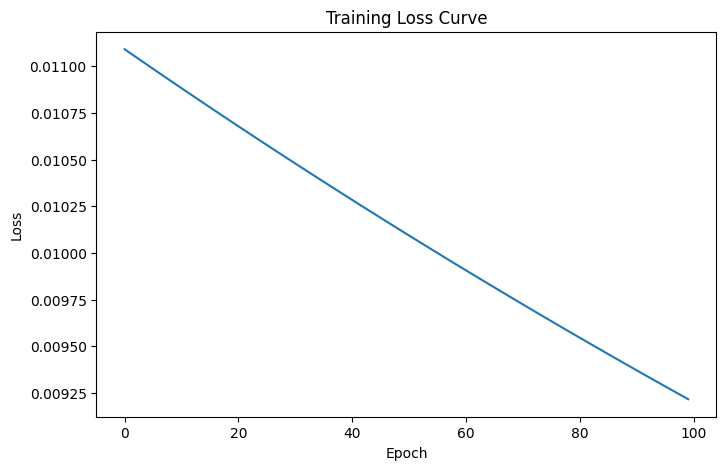

In [152]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

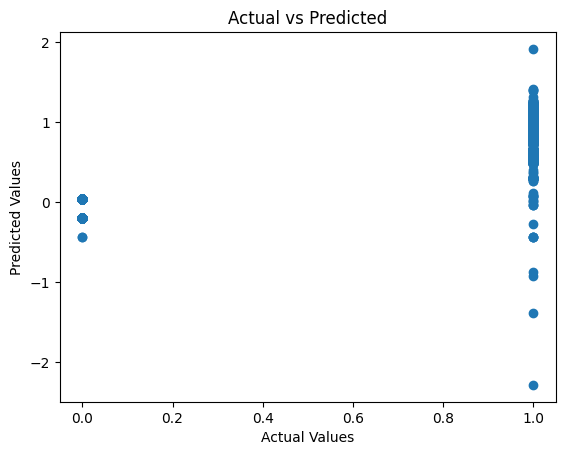

In [153]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

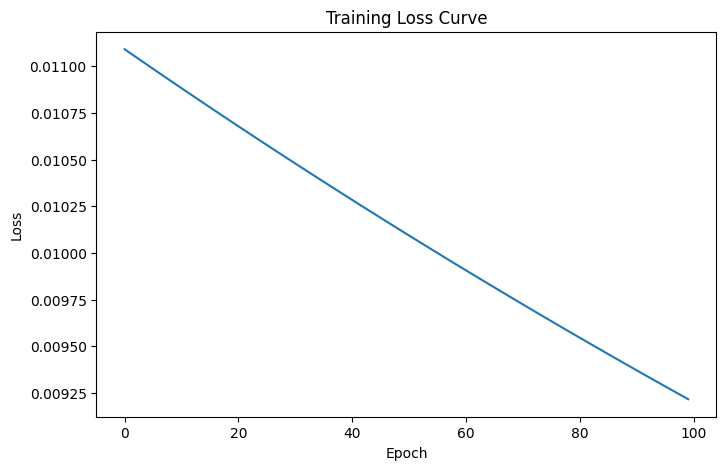

In [154]:
plt.figure(figsize=(8,5))
plt.plot(losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("loss_curve.png")

plt.show()